# Machine learning tutorial (Python)
This project is adapted from the tuotrial "Your First Machine Learning Project in Python Step-By-Step" by Jason Brownlee.
https://machinelearningmastery.com/machine-learning-in-python-step-by-step/

In [2]:
# load libraries
import scipy
import numpy
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from pandas import read_csv
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


## Import data

In [3]:
# Load dataset
file = "/Users/coraalbers/Documents/sum26/7030_data_sci/assignment5/data/iris.csv"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
dataset = read_csv(file, names=names)

In [4]:
# shape
print(dataset.shape)
print(dataset.head(20))

# descriptions
print(dataset.describe())

# class distribution
print(dataset.groupby('class').size())

(150, 5)
    sepal-length  sepal-width  petal-length  petal-width        class
0            5.1          3.5           1.4          0.2  Iris-setosa
1            4.9          3.0           1.4          0.2  Iris-setosa
2            4.7          3.2           1.3          0.2  Iris-setosa
3            4.6          3.1           1.5          0.2  Iris-setosa
4            5.0          3.6           1.4          0.2  Iris-setosa
5            5.4          3.9           1.7          0.4  Iris-setosa
6            4.6          3.4           1.4          0.3  Iris-setosa
7            5.0          3.4           1.5          0.2  Iris-setosa
8            4.4          2.9           1.4          0.2  Iris-setosa
9            4.9          3.1           1.5          0.1  Iris-setosa
10           5.4          3.7           1.5          0.2  Iris-setosa
11           4.8          3.4           1.6          0.2  Iris-setosa
12           4.8          3.0           1.4          0.1  Iris-setosa
13         

## Plot data distributions
Generate box and whisker plots, histograms and scatter matrices to look at the general data distribution.

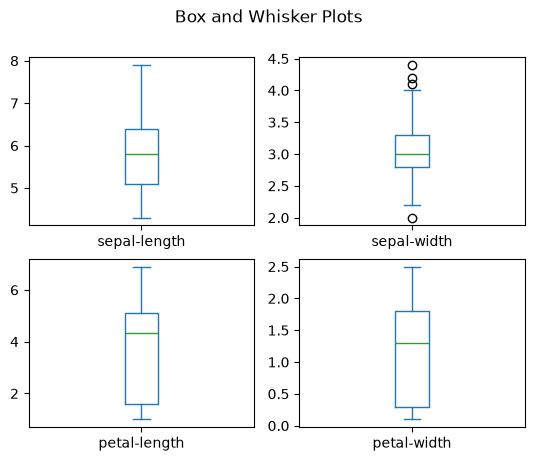

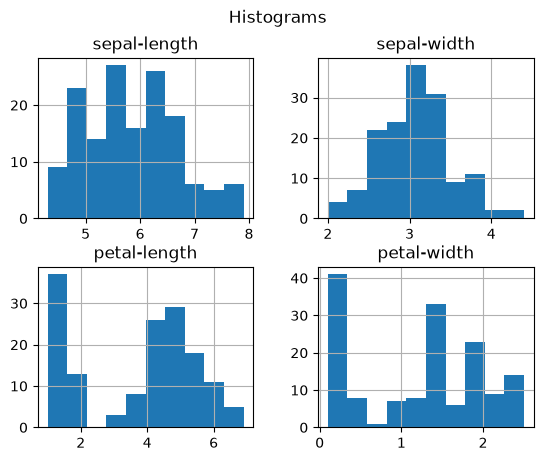

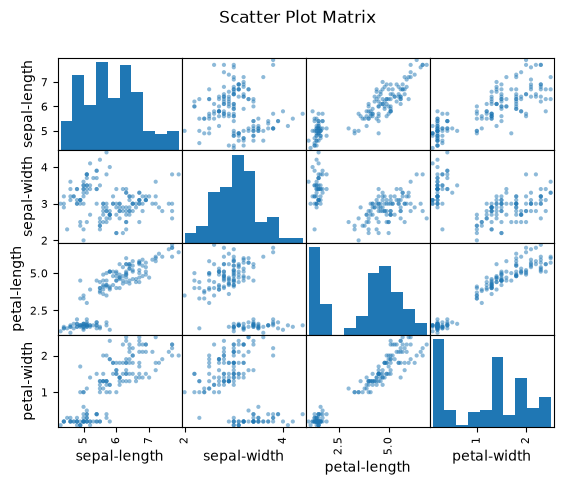

In [7]:
# box and whisker plots
dataset.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.suptitle("Box and Whisker Plots")
plt.show()

# histograms 
dataset.hist()
plt.suptitle("Histograms")
plt.show()

# scatter plot matrix
scatter_matrix(dataset)
plt.suptitle("Scatter Plot Matrix")
plt.show()

## Set up and validate ML models
1. Split the data into training and test data
2. Compile list of models to be evaluated
3. Run 10-fold cross validation on each of the models 
4. Compare algorithms to find the accurate model

LR: 0.966667 (0.040825)
LDA: 0.975000 (0.038188)
KNN: 0.958333 (0.041667)
CART: 0.958333 (0.041667)
NB: 0.950000 (0.055277)
SVM: 0.983333 (0.033333)


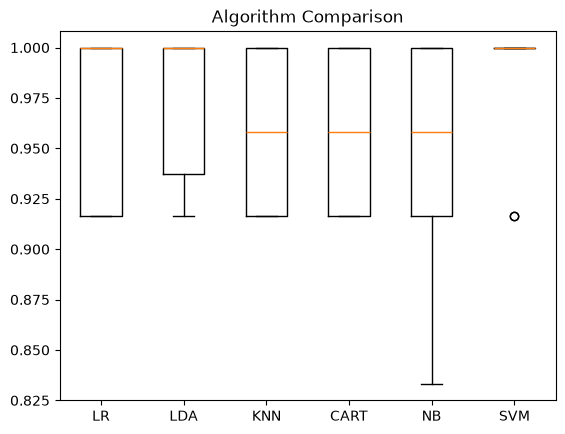

In [5]:
# Split the dataset to make a validation dataset
array = dataset.values
x = array[:,0:4]
y = array[:,4]
x_train, x_validation, y_train, y_validation = train_test_split(x, y, test_size=0.20, random_state=1)

# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))


# evaluate each model in turn using 10-fold cross-validation
results = []
names = []
for name, model in models: # for each model
	kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
	cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='accuracy')
	results.append(cv_results)
	names.append(name)
	print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))


# Compare Algorithms
plt.boxplot(results, tick_labels=names)
plt.title('Algorithm Comparison')
plt.show()

## Evaluate predictions on validation data
Using the most accurate model, evaluate the predictions of the model using the validation data.

In [6]:
# Make predictions on validation dataset
model = SVC(gamma='auto')
model.fit(x_train, y_train)
predictions = model.predict(x_validation)

# Evaluate predictions
print(accuracy_score(y_validation, predictions))
print(confusion_matrix(y_validation, predictions))
print(classification_report(y_validation, predictions))

0.9666666666666667
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.97        30
      macro avg       0.95      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30

